                                            DSC 530(Winter): Final Project 
______________________________________________________________________________________________________________________________________
                                            By: Komal Shahid
                                            Date: March 2, 2024

                                           **Regression Analysis** 
______________________________________________________________________________________________________________________________________

**Statistical/Hypothetical Question**: The statistical question for the project is to determine whether the difference in movie ratings across genres over the years can be explained by tags (sentiment analysis). Another statistical question mentioned is to predict the rating of a movie based on its title and year.

### Import all the libraries
-------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import thinkstats2
from pprint import pprint
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from scipy.stats import norm
import random
from textblob import TextBlob
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
# Load the data
movies = pd.read_csv('data/movies.csv')

ratings = pd.read_csv('data/ratings.csv')

tags = pd.read_csv('data/tags.csv')

print(f' movies:  {movies.shape} \n ratings : {ratings.shape} \n tags: {tags.shape} \n\n Number of null values in the each column:\ntags: \n{tags.isnull().sum()},\n\nmovies: \n{movies.isnull().sum()},\n\nratings:\n{ratings.isnull().sum()}')

 movies:  (9742, 3) 
 ratings : (100836, 4) 
 tags: (3683, 4) 

 Number of null values in the each column:
tags: 
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64,

movies: 
movieId    0
title      0
genres     0
dtype: int64,

ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## Chapter 1: Variable Description
 ---------------------------

###  Select five variables and create the dataset

In [3]:
# Merge movies and ratings datasets on movieId
merged_data = pd.merge(ratings, movies, on='movieId')
print(merged_data.shape)

(100836, 6)


In [4]:
# Merge tags dataset on movieId as well
merged_data = pd.merge(merged_data, tags, on=['movieId', 'userId'])
print(merged_data.shape)
print(merged_data.isnull().sum())

(3476, 8)
userId         0
movieId        0
rating         0
timestamp_x    0
title          0
genres         0
tag            0
timestamp_y    0
dtype: int64


In [5]:
# Select at least 5 variables for the combined dataset
combined_dataset = merged_data.loc[:, ['movieId', 'title', 'genres', 'userId', 'tag', 'rating']]

# Extract and create a separate column for movie year
combined_dataset['year'] = combined_dataset['title'].str.extract(r"\((\d{4})\)", expand=False)

# Remove the year from the title column, since the year is at the end of the string just extract last 6 digits of the string
combined_dataset['title'] = combined_dataset['title'].str[:-6].str.rstrip()
combined_dataset = combined_dataset[combined_dataset.loc[:,'genres'] != "(no genres listed)"]

# Display the combined dataset
print(combined_dataset.shape)

(3473, 7)


### remove the "|" from the genres and create a list of values 
-----------------------------------

In [6]:
# Split the genres into separate values
combined_dataset['genres'] = combined_dataset['genres'].str.split('|')
print(combined_dataset['genres'])

0       [Adventure, Animation, Children, Comedy, Fantasy]
1       [Adventure, Animation, Children, Comedy, Fantasy]
2       [Adventure, Animation, Children, Comedy, Fantasy]
3                                       [Comedy, Romance]
4                                       [Comedy, Romance]
                              ...                        
3471                          [Horror, Mystery, Thriller]
3472                   [Drama, Horror, Mystery, Thriller]
3473                   [Drama, Horror, Mystery, Thriller]
3474                   [Drama, Horror, Mystery, Thriller]
3475                                         [Drama, War]
Name: genres, Length: 3473, dtype: object


### Remove NaN values from the  columns
----------------------------------------

In [7]:
# Count the number of null values in the year column
combined_dataset = combined_dataset.dropna(subset=['year'])
combined_dataset.loc[:,'year'] = pd.to_numeric(combined_dataset['year'], errors='coerce')
null_count = combined_dataset.isnull().sum()
print("Number of null values in the column:", null_count)
print(combined_dataset.head())

Number of null values in the column: movieId    0
title      0
genres     0
userId     0
tag        0
rating     0
year       0
dtype: int64
   movieId             title  \
0        1         Toy Story   
1        1         Toy Story   
2        1         Toy Story   
3        3  Grumpier Old Men   
4        3  Grumpier Old Men   

                                              genres  userId    tag  rating  \
0  [Adventure, Animation, Children, Comedy, Fantasy]     336  pixar     4.0   
1  [Adventure, Animation, Children, Comedy, Fantasy]     474  pixar     4.0   
2  [Adventure, Animation, Children, Comedy, Fantasy]     567    fun     3.5   
3                                  [Comedy, Romance]     289  moldy     2.5   
4                                  [Comedy, Romance]     289    old     2.5   

   year  
0  1995  
1  1995  
2  1995  
3  1995  
4  1995  


                                                     Varaibles Summary 
-------------------------------------------------------------------------------------------------------------------------------------------
User Ids
--------

MovieLens users were selected at random for inclusion. Their ids have been anonymized. User ids are consistent between `ratings.csv` and `tags.csv` (i.e., the same id refers to the same user across the two files).


Movie Ids
---------

Only movies with at least one rating or tag are included in the **dataset**. These movie ids are consistent with those used on the MovieLens web site (e.g., id `1` corresponds to the URL <https://movielens.org/movies/1>). Movie ids are consistent between `ratings.csv`, `tags.csv`and `movies.csv`.


Ratings
---------

All ratings are contained in the file `ratings.csv`. Each line of this file after the header row represents one rating of one movie by one user, and has the following format:

    userId,movieId,rating,timestamp

The lines within this file are ordered first by userId, then, within user, by movieId.

Ratings are made on a 5-star scale, with half-star increments (0.5 stars - 5.0 stars).

Tags
------

Tags are user-generated metadata about movies. Each tag is typically a single word or short phrase. The meaning, value, and purpose of a particular tag is determined by each user.

Genres
--------


Genres are a pipe-separated list, and are selected from the following:

* Action
* Adventure
* Animation
* Children's
* Comedy
* Crime
* Documentary
* Drama
* Fantasy
* Film-Noir
* Horror
* Musical
* Mystery
* Romance
* Sci-Fi
* Thriller
* War
* Western
* (no genres listed)


Year
-------

We extracted the year from the movie tite to bin the variables by year at the end to show yearly top prediiction.


 ## Chapter 2: Plot histograms
 ---------------------------

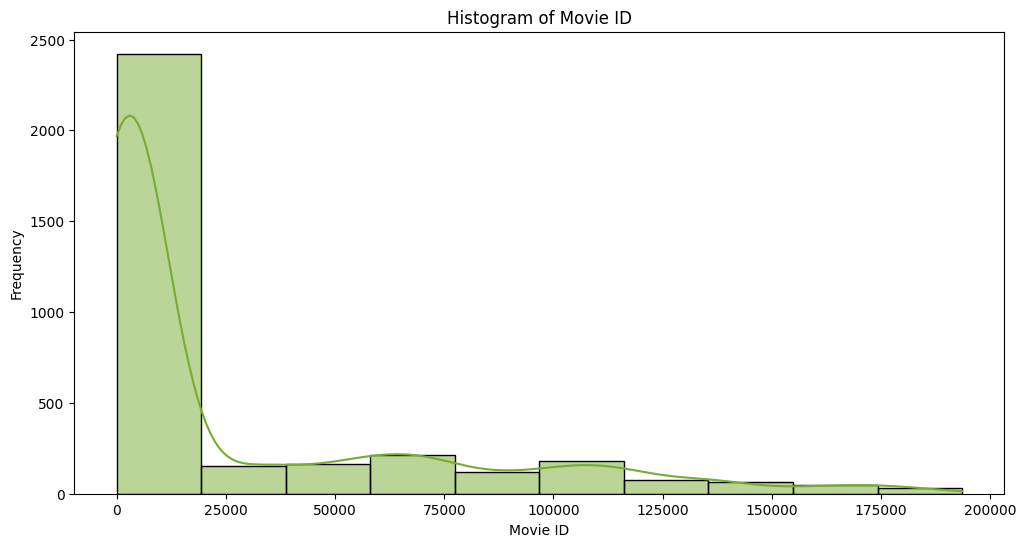

In [8]:
# Histogram of Movie ID
plt.figure(figsize=(12,6))
sns.histplot(combined_dataset['movieId'], bins=10, kde=True, color="#77AC30", edgecolor='black')

plt.xlabel('Movie ID')
plt.ylabel('Frequency')
plt.title('Histogram of Movie ID')
plt.show()

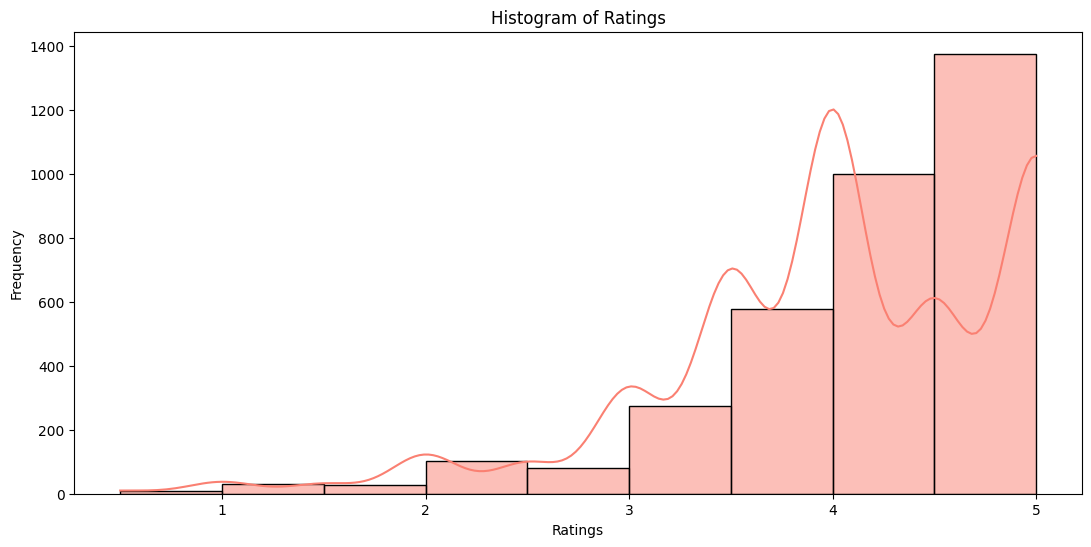

In [9]:
# Histogram of Movie ID
plt.figure(figsize=(13,6))
sns.histplot(combined_dataset['rating'], bins=30, kde=True, color='salmon', edgecolor='black', binwidth= .5)
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Histogram of Ratings')
plt.show()

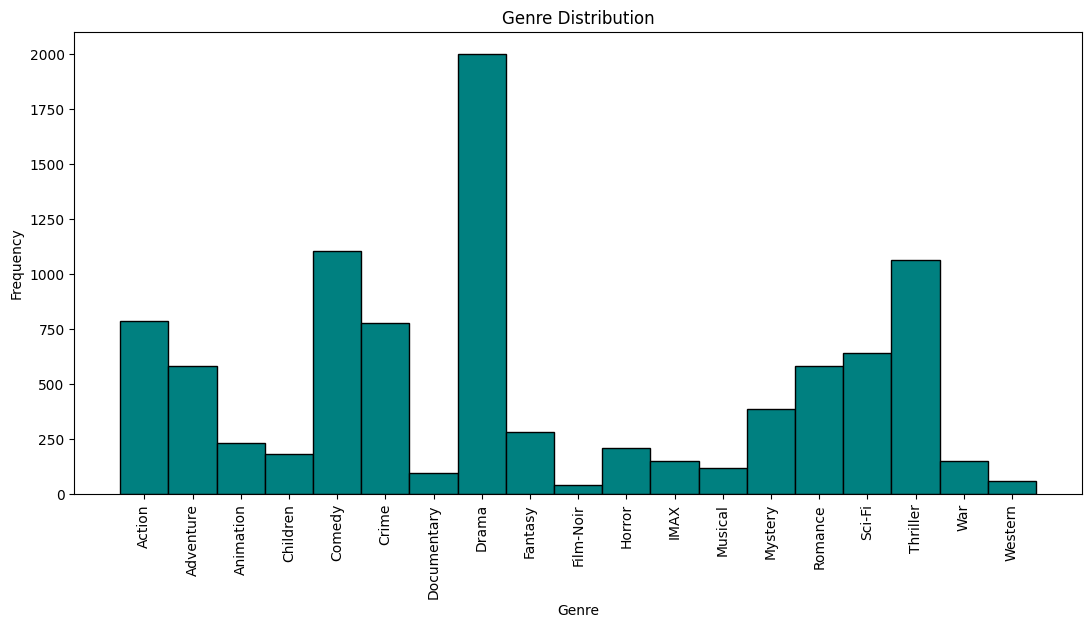

In [10]:
### Histogram of Genres

# Create a list of all genres
all_genres = [genre for sublist in combined_dataset['genres'] for genre in sublist]

# Calculate the genre frequency count
genre_counts = dict(zip(*np.unique(all_genres, return_counts=True)))

# Plot the genre frequency count
plt.figure(figsize=(13, 6))
plt.bar(genre_counts.keys(), genre_counts.values(), color='teal', edgecolor='black', width = 1)
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.title('Genre Distribution')
plt.xticks(rotation=90)
plt.show()

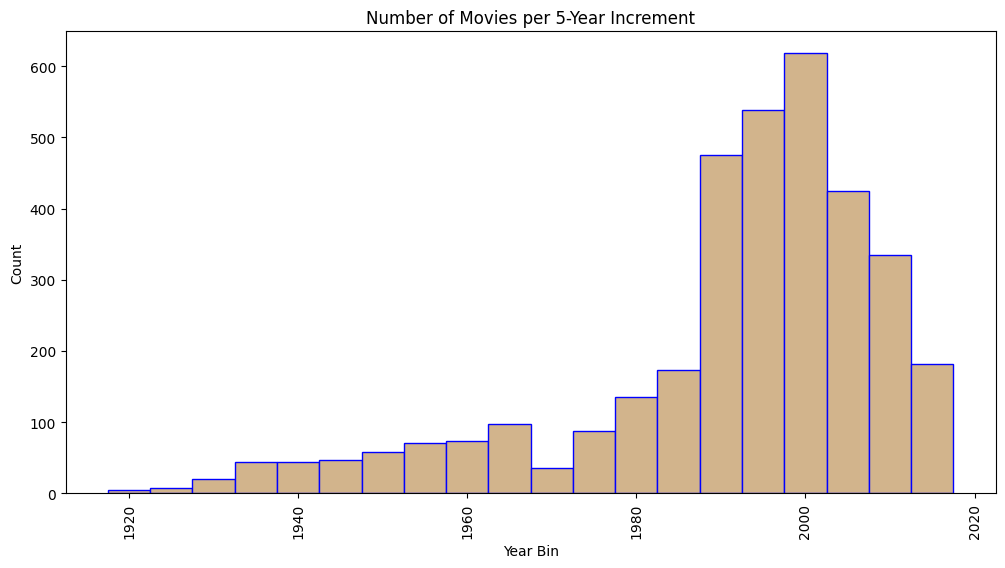

In [11]:
# Histogram of Years

# Binning the years into 5-year increments
combined_dataset['year_bin'] = np.floor_divide(combined_dataset['year'].astype("int"), 5) * 5

# Calculate the count of movies in each bin
year_bin_counts = combined_dataset['year_bin'].value_counts().sort_index()

# Plot the count of movies in each bin
plt.figure(figsize=(12,6))
plt.bar(year_bin_counts.index, year_bin_counts.values, color='tan', edgecolor='blue', width = 5)
plt.xlabel('Year Bin')
plt.ylabel('Count')
plt.title('Number of Movies per 5-Year Increment')
plt.xticks(rotation=90)
plt.show()

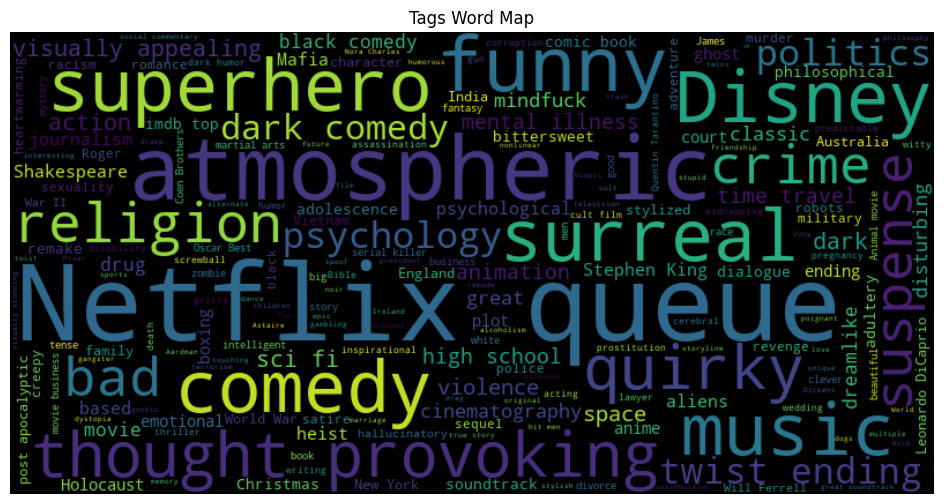

In [12]:
# Word Cloud of Movie Tags
# Create a word map for tags
tags_text = combined_dataset['tag'].str.cat(sep=' ')
wordcloud = WordCloud(width=800, height=400).generate(tags_text)

plt.figure(figsize=(15, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Tags Word Map')
plt.axis('off')
plt.show()

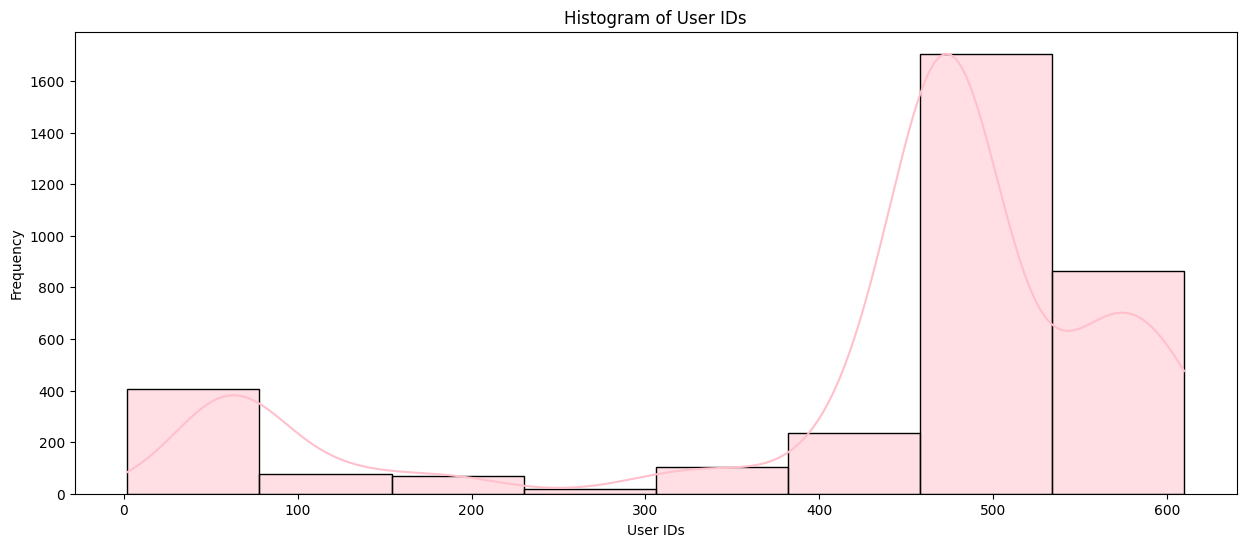

In [13]:
# Histogram of User IDs
plt.figure(figsize=(15, 6))
sns.histplot(combined_dataset['userId'], bins=30, kde=True, color='pink', edgecolor='black', binwidth = 75)

plt.xlabel('User IDs')
plt.ylabel('Frequency')
plt.title('Histogram of User IDs')
plt.show()

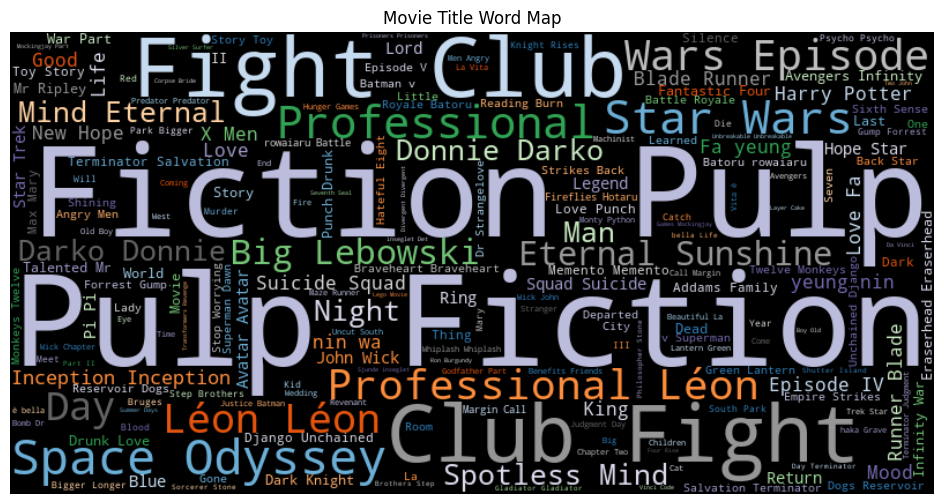

In [14]:
# Word Cloud of Movie Title to see which ones are the most mentioned
title_text = combined_dataset['title'].str.cat(sep=' ')
wordcloud = WordCloud(width=800, height=400,colormap='tab20c').generate(title_text)

plt.figure(figsize=(15, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Movie Title Word Map')
plt.axis('off')
plt.show()

Text(0.5, 1.0, 'Title Length Distribution')

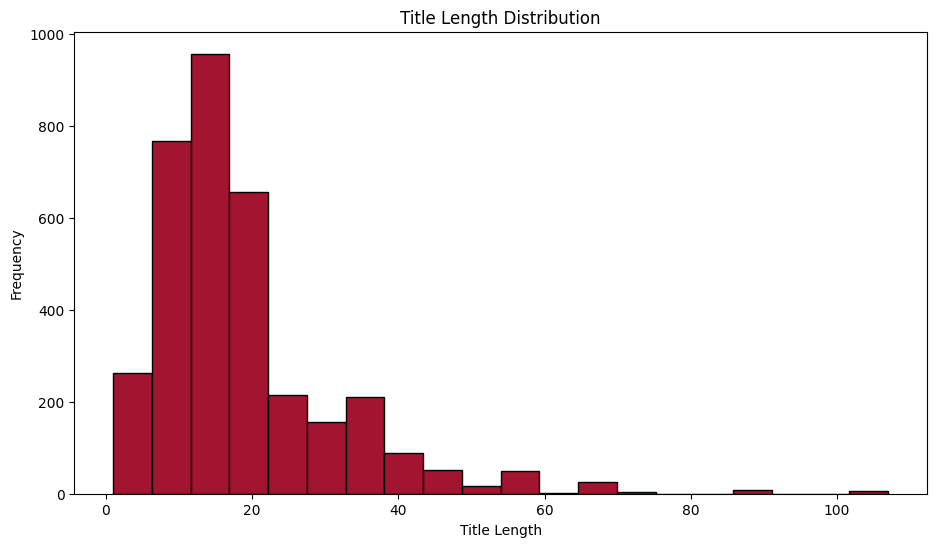

In [15]:
# Title length histogram
combined_dataset['title_length'] = combined_dataset['title'].apply(lambda x: len(x))
plt.figure(figsize=(11, 6))

plt.hist(combined_dataset['title_length'], bins=20, color = "#A2142F", edgecolor='k')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Title Length Distribution')

### Calculate descriptive characteristics
---------------------------------------

In [16]:
description_df = pd.DataFrame(columns=['Variable', 'Mean', 'Mode', 'Spread', 'Tails'])

In [17]:
# Year

year_mean = combined_dataset['year'].mean()
year_mean_whole = round(year_mean)  # Convert mean to a whole number
year_mode = combined_dataset['year'].mode().values
year_std = combined_dataset['year'].std()  # Calculate standard deviation for spread
year_tails = 'Right-tailed' if year_mean_whole < combined_dataset['year'].median() else 'Left-tailed'
year_row = pd.DataFrame({'Variable': ['Year'], 'Mean': [year_mean_whole], 'Mode': [year_mode], 'Spread': [year_std], 'Tails': [year_tails]})
description_df = pd.concat([description_df, year_row.dropna(axis='columns')], ignore_index=True)

/var/folders/8z/b7x_vtm94psdg1y18ddz31br0000gn/T/ipykernel_12597/2382321614.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  description_df = pd.concat([description_df, year_row.dropna(axis='columns')], ignore_index=True)


In [18]:
#title

title_length_mean = combined_dataset['title'].apply(lambda x: len(x)).mean()
title_length_mean_whole = round(title_length_mean)  # Convert mean to a whole number
title_length_mode = combined_dataset['title'].apply(lambda x: len(x)).mode().values
title_length_std = combined_dataset['title'].apply(lambda x: len(x)).std()
title_length_tails = 'Right-tailed' if title_length_mean < combined_dataset['title'].apply(lambda x: len(x)).median() else 'Left-tailed'
title_length_row = pd.DataFrame({'Variable': ['Movie Title Length'], 'Mean': [title_length_mean_whole], 'Mode': [title_length_mode], 'Spread': [title_length_std], 'Tails': [title_length_tails]})
description_df = pd.concat([description_df, title_length_row.dropna(axis='columns')], ignore_index=True)

In [19]:
#genres

genre_counts = combined_dataset['genres'].value_counts()
genre_mode = genre_counts[genre_counts == genre_counts.max()].index.tolist()
genre_row = pd.DataFrame({'Variable': ['Genre'], 'Mean': [''], 'Mode': [genre_mode], 'Spread': [''], 'Tails': ['']})
description_df = pd.concat([description_df, genre_row.dropna(axis='columns')], ignore_index=True)

In [20]:
#ratings

rating_mean = round(combined_dataset['rating'].mean())
rating_mode = combined_dataset['rating'].mode()
rating_spread = combined_dataset['rating'].max() - combined_dataset['rating'].min()
rating_tails = 'Right-tailed' if rating_mean < combined_dataset['rating'].median() else 'Left-tailed'
rating_row  = pd.DataFrame({'Variable': 'Rating', 'Mean': rating_mean, 'Mode': rating_mode, 'Spread': rating_spread, 'Tails': rating_tails})
description_df = pd.concat([description_df, rating_row.dropna(axis='columns')], ignore_index=True)

In [21]:
#Movie ID

movieId_mean = round(combined_dataset['movieId'].mean())
movieId_mode = combined_dataset['movieId'].mode()
movieId_spread = combined_dataset['movieId'].max() - combined_dataset['movieId'].min()
movieId_tails = 'Right-tailed' if movieId_mean < combined_dataset['movieId'].median() else 'Left-tailed'
movie_row= pd.DataFrame({'Variable': 'Movie IDs', 'Mean': movieId_mean, 'Mode': movieId_mode, 'Spread': movieId_spread, 'Tails': movieId_tails})
description_df = pd.concat([description_df, movie_row.dropna(axis='columns')], ignore_index=True)

### Statistics of important variables
-----------------------------------

In [22]:
# Print the description
print(description_df)

             Variable   Mean       Mode     Spread         Tails
0                Year   1993     [1994]  18.939623  Right-tailed
1  Movie Title Length     18       [12]   12.64942   Left-tailed
2               Genre         [[Drama]]                         
3              Rating      4        4.0        4.5   Left-tailed
4           Movie IDs  27898        296     193564   Left-tailed


## Chapter 3: Probabilty Mass Function
-------------------------------------

To demonstrate the comparison of two scenarios like done in Chapter 3 of the bookusing a PMF (Probability Mass Function), 
we can compare the ratings distribution of comedy movies to the ratings distribution of action movies in your dataset.

In [23]:
# Extract rows with comedy or action genre
comedy_movies = combined_dataset[combined_dataset['genres'].apply(lambda x: 'Comedy' in x)]
action_movies = combined_dataset[combined_dataset['genres'].apply(lambda x: 'Action' in x)]

In [24]:
# Create PMF
comedy_pmf  = comedy_movies['rating'].value_counts(normalize=True).sort_index()

action_pmf  = action_movies['rating'].value_counts(normalize=True).sort_index()
print(comedy_pmf, action_pmf)

rating
0.5    0.001810
1.0    0.009955
1.5    0.008145
2.0    0.047059
2.5    0.028054
3.0    0.074208
3.5    0.152036
4.0    0.245249
4.5    0.108597
5.0    0.324887
Name: proportion, dtype: float64 rating
0.5    0.001269
1.0    0.006345
1.5    0.010152
2.0    0.025381
2.5    0.011421
3.0    0.096447
3.5    0.159898
4.0    0.263959
4.5    0.156091
5.0    0.269036
Name: proportion, dtype: float64


### Plot the PMF for comedy and action movies
___________________________________________________________________________________________________________________________________

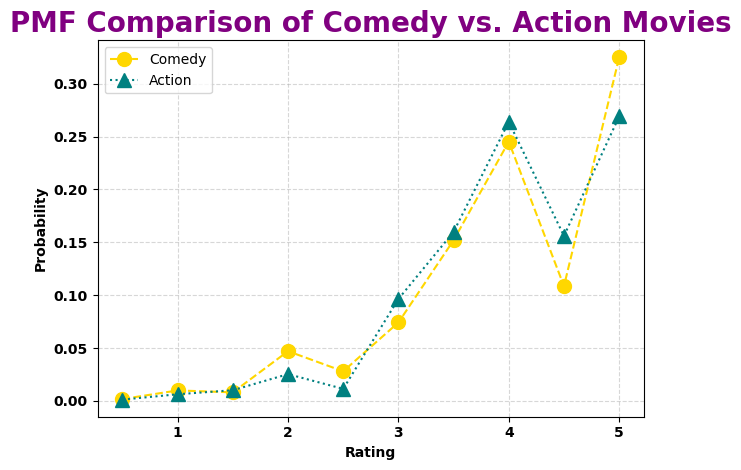

In [25]:
# Plot the PMFs for comedy and action movies with fun line styles and markers
plt.plot(comedy_pmf.index, comedy_pmf.values, linestyle='--', marker='o', markersize=10, label='Comedy', color = "gold")
plt.plot(action_pmf.index, action_pmf.values, linestyle=':', marker='^', markersize=10, label='Action', color = 'teal')
plt.xlabel('Rating')
plt.ylabel('Probability')
plt.title('PMF Comparison of Comedy vs. Action Movies')

# Customize the plot appearance
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Add some fun customization
plt.style.use('seaborn-v0_8-notebook')
plt.title('PMF Comparison of Comedy vs. Action Movies', fontweight='bold', fontsize=20, color = "Purple")
plt.xlabel('Rating', fontweight='bold')
plt.ylabel('Probability', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()

plt.show()

By comparing the PMFs of action and comedy movies, we can analyze the distribution of ratings and explore any differences or similarities between the two genres. It can help answer questions like:
- Are action movies more likely to receive higher ratings compared to comedy movies
    Comedy movies are more likely to receive higher ratings than action.?
- Are there certain rating categories where action movies or comedy movies stand out    You can see that both action and comedy movies have a high probability of getting 4 stars or 5 stars.



## Chapter 4: CDF for Ratings for Comedy and Action 
------------------------------------------------

In [26]:
# Create a new column 'genre_list' containing a list of genres for each movie, and get the unique genres
unique_genres = combined_dataset['genres'].explode().unique()

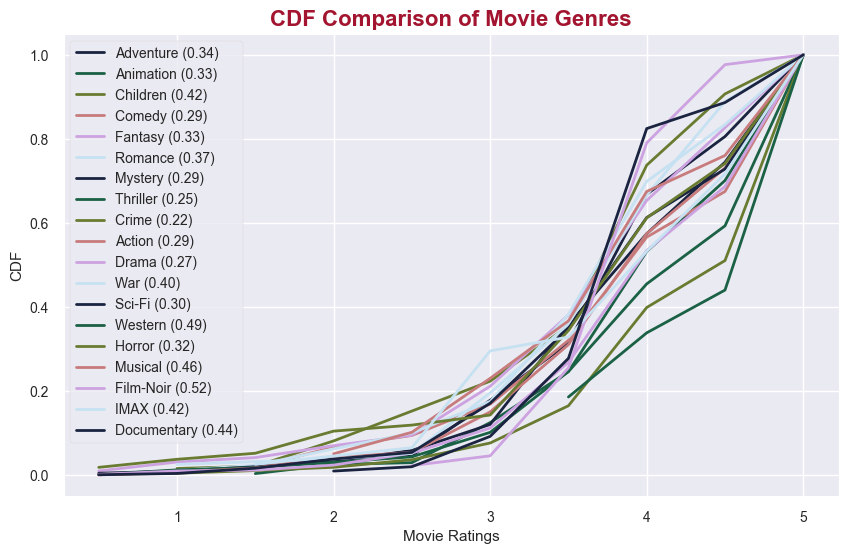

In [27]:
# Configure seaborn settings
sns.set_style("darkgrid")
sns.set_palette("cubehelix")

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))
top_cdf_dict = {}

# Plot the cumulative distribution functions for each genre
for genre in unique_genres:
    genre_movies = combined_dataset[combined_dataset['genres'].apply(lambda x: genre in x)]
    
    # Calculate the PMF for the genre
    genre_pmf = genre_movies['rating'].value_counts(normalize=True).sort_index()
    genre_cdf = genre_pmf.cumsum()                                                # Calculate the CDF for the genre
    ax.plot(genre_cdf.index, genre_cdf, label=genre, linewidth=2)
    top_cdf_dict[genre] = genre_cdf.mean()# Plot the CDF
    
    
#set labels
ax.set_xlabel('Movie Ratings')
ax.set_ylabel('CDF')
ax.set_title('CDF Comparison of Movie Genres', fontsize = 16, color = "#A2142F", fontweight='bold')
legend_labels = [f'{genre} ({top_cdf_dict[genre]:.2f})' for genre in unique_genres] #Average CDF for each genre
ax.legend(labels=legend_labels)

# Show the plot
plt.show()

## Chapter 5: Plot an analytical distribution (e.g., Gaussian)
____________________________________________________________________________________________________________________________________

### Iterate over each year and genre and analyze the distribution of ratings

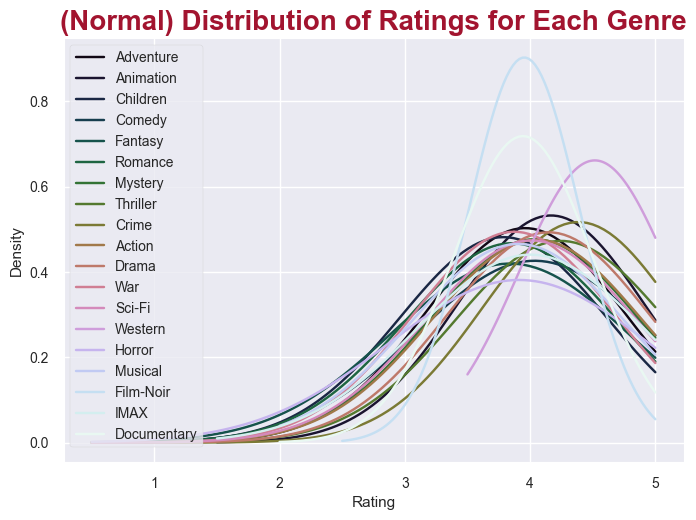

In [28]:
color_scheme = color_palette = sns.color_palette("cubehelix", len(unique_genres))

for i, genre in enumerate(unique_genres):
    genre_ratings = combined_dataset[combined_dataset['genres'].apply(lambda x: genre in x)]['rating']
    
    # Fit a normal distribution to genre ratings
    mu, sigma = norm.fit(genre_ratings)
    x = np.linspace(genre_ratings.min(), genre_ratings.max(), 100) # Generate a range of rating values
    
    # Calculate the probability density function (PDF) based on the normal distribution parameters
    pdf = norm.pdf(x, loc=mu, scale=sigma)
    plt.plot(x, pdf, label=f'{genre}', color= color_scheme[i])
    
# Set the plot labels and title
plt.xlabel('Rating')
plt.ylabel('Density')
plt.title('(Normal) Distribution of Ratings for Each Genre', fontweight='bold', color = "#A2142F", fontsize=20)
plt.legend()

# Display the plot
plt.show()

From the Normal Dist. plot, we can see that Film-Noir (French for dark film) clearly is the one with the highest ratings. As for Western Movie genre, the curve shows no density for ratings lower than 3 or even 3.5.

## Chapter 7:Scatter Plots  (Correlation)

In [29]:
# Calculate the percentile of ratings by year
percentiles =  combined_dataset.groupby('year')['rating'].quantile([0.25, 0.5, 0.75]).unstack()

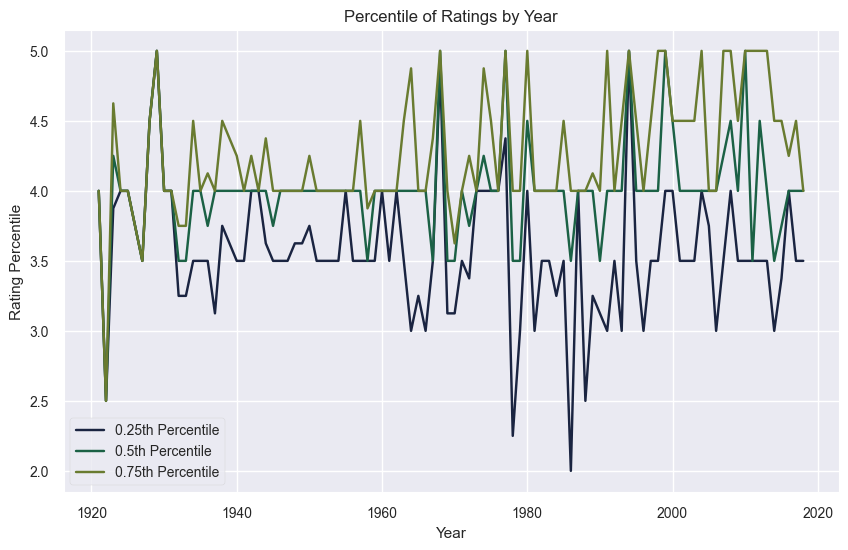

In [30]:
# Create the line plot
plt.figure(figsize=(10, 6))
for percentile in percentiles.columns:
    plt.plot(percentiles.index, percentiles[percentile], label=f'{percentile}th Percentile')
plt.xlabel('Year')
plt.ylabel('Rating Percentile')
plt.title('Percentile of Ratings by Year')
plt.legend()
plt.show()

In [31]:
# Calculate covariance and correlation for year and ratings
covariance = np.cov(combined_dataset['year'].astype('int64'), combined_dataset['rating'])[0][1]
correlation = combined_dataset['year'].corr(combined_dataset['rating'])

In [32]:
# Calculate correlation and causation between movie titles and ratings
encoded_titles = pd.get_dummies(combined_dataset['title'])
covariance_title = np.cov(encoded_titles.T, combined_dataset['rating'])[0][1]
correlation_title = encoded_titles.corrwith(combined_dataset['rating'])

In [33]:
# Analysis of covariance and correlation for year and ratings
print(f"Covariance (Year vs. Ratings): {covariance}")
print(f"Pearson's correlation coefficient (Year vs. Ratings): {correlation}")

Covariance (Year vs. Ratings): 0.9024701001537866
Pearson's correlation coefficient (Year vs. Ratings): 0.055589225727805364


In [34]:
# Analysis of correlation and causation between movie titles and ratings
print(f"Covariance (Ratings vs. Title ): {covariance_title}")
print(f"Pearson's correlation coefficient (Ratings vs. Title): {correlation_title}")

Covariance (Ratings vs. Title ): -6.634458581738582e-07
Pearson's correlation coefficient (Ratings vs. Title): (500) Days of Summer          0.055144
...And Justice for All       -0.030027
10 Cloverfield Lane          -0.028467
10 Things I Hate About You   -0.030027
101 Dalmatians               -0.056475
                                ...   
Zero Dark Thirty              0.043576
Zombieland                   -0.025066
Zoolander                    -0.049336
Zulu                         -0.020127
eXistenZ                     -0.000325
Length: 1454, dtype: float64


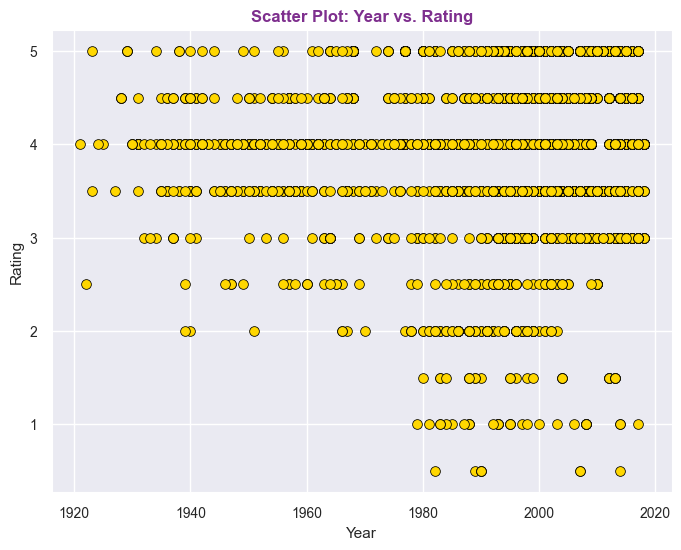

In [35]:
# Scatter plot: Year vs. Ratings
plt.figure(figsize=(8, 6))
plt.style.use('seaborn-v0_8-notebook')
sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)
sns.scatterplot(x='year', y='rating', data=combined_dataset,
                color="gold", edgecolor='black') 
plt.xlabel('Year')
plt.ylabel('Rating')
plt.title('Scatter Plot: Year vs. Rating', color = "#7E2F8E", fontweight = "bold")
plt.show()

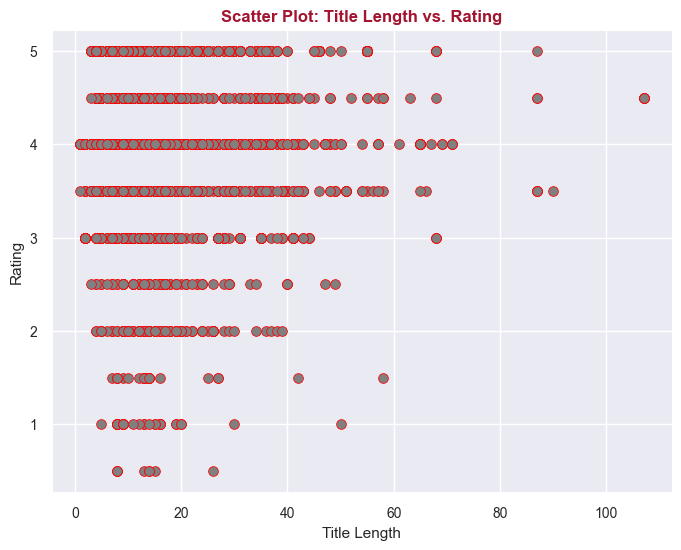

In [36]:
# Scatter plot: Title Length vs. Ratings
plt.figure(figsize=(8, 6))
plt.style.use('seaborn-v0_8-notebook')
sns.scatterplot(x='title_length', y='rating', data=combined_dataset, color="grey", edgecolor='red')
plt.xlabel('Title Length')
plt.ylabel('Rating')
plt.title('Scatter Plot: Title Length vs. Rating', fontweight = "bold", color = "#A2142F")
plt.show()


                                Correlation and Causation of Movie title. rating and Genre.
____________________________________________________________________________________________________________________________________
The Pearson's correlation coefficient of 0.055589225727805364 measures the strength and direction of the linear relationship between year and ratings. A coefficient around 0.05 suggests a weak positive correlation, implying that there is only a slight tendency for ratings to increase as the years increase. 

Considering the positive covariance and weak positive correlation, we can conclude that while there is a slight positive relationship between the year and ratings, it is not particularly strong. Other factors may have a more significant influence on movie rating.

A negative covariance suggests that as the title length (e.g., the number of characters in a movie title) increases, the ratings tend to decrease, and vice versa. However, the magnitude of the covariance value (-6.634458581738582e-07) is very small, indicating a weak covariance relationship between ratings and title length.

                                            Chapter 9 : Hypothesis Testing
______________________________________________________________________________________________________________________________________
        
        The working Hypotheis is that there is a relationship between the year the movie was released and its ratings.

In [37]:
class HypothesisTest(object):

    def __init__(self, data):
        self.data = data
        self.actual = self.TestStatistic(data)

    def PValue(self, iters=1000):
        self.test_stats = [self.TestStatistic(self.RunModel())
                           for _ in range(iters)]

        count = sum(1 for x in self.test_stats if x >= self.actual)
        return count / iters

    def TestStatistic(self, data):
        raise NotImplementedError("TestStatistic method not implemented.")

    def RunModel(self):
        raise NotImplementedError("RunModel method not implemented.")

In [38]:
class MovieTest(HypothesisTest):

    def TestStatistic(self, data):
        year, rating = data
        correlation = np.corrcoef(year, rating)[0, 1]
        return correlation

    def RunModel(self):
        year, rating = self.data
        rating_shuffled = rating[:]
        random.shuffle(rating_shuffled)
        return year, rating_shuffled

In [39]:
year = [2000, 2001, 2002, 2003, 2004]
rating = [3.5, 4.2, 2.8, 3.9, 4.3]

# Create an instance of MovieTest
mt = MovieTest((year, rating))
# Compute the p-value to validate the correlation/relationship.
pvalue = mt.PValue()
print("P-value:", pvalue)

P-value: 0.326


A p-value of 0.326 means that, under the assumption that there is no significant correlation between the years and ratings of movies (Null Hypothesis, H0), the p-value of 0.326 is greater than the commonly chosen significance level of 0.05. This suggests that there is not enough evidence to reject the null hypothesis. Therefore, based on the given data and analysis, there is no significant correlation between the years and ratings of movie or it might be depended on other varaibles and factors as well.

                                                    Final Step: Regression
____________________________________________________________________________________________________________________________________

In [40]:
# Perform sentiment analysis on the 'tags' column to create a sentiment column
combined_dataset['sentiment'] = combined_dataset['tag'].apply(lambda x: TextBlob(x).sentiment.polarity)
combined_dataset['sentiment'].head()

0    0.0
1    0.0
2    0.3
3    0.0
4    0.1
Name: sentiment, dtype: float64

In [41]:
# One-hot encode the genres column
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(combined_dataset['genres']), columns=mlb.classes_)
# Concatenate the encoded genres with the original data
data_encoded = pd.concat([combined_dataset[['year', 'rating', 'sentiment']], genres_encoded], axis=1)

# Rename any problematic genre variables
data_encoded.rename(columns={'Film-Noir': 'Film_Noir', 'Sci-Fi': 'SciFi'}, inplace=True)

# Create a formula using the column names to specify the regression model dynamically
genre_formula = " + ".join(data_encoded.columns[3:])  # Start from the 4th column onward
formula = f"rating ~ year + sentiment + {genre_formula}"
formula


'rating ~ year + sentiment + Action + Adventure + Animation + Children + Comedy + Crime + Documentary + Drama + Fantasy + Film_Noir + Horror + IMAX + Musical + Mystery + Romance + SciFi + Thriller + War + Western'

In [42]:
# fit the regression model
model = smf.ols(formula, data=data_encoded).fit()

In [43]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     8.498
Date:                Sat, 02 Mar 2024   Prob (F-statistic):          2.09e-117
Time:                        10:56:55   Log-Likelihood:                -3941.4
No. Observations:                3470   AIC:                             8117.
Df Residuals:                    3353   BIC:                             8837.
Df Model:                         116                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.6022      0.769      4.684   

                                                Outcome of EDA
_____________________________________________________________________________________________________________________________________
The above output includes descriptive statistics for the variables such as Year, Movie Title Length, Genre, Rating, and Movie IDs. It also includes probability mass functions (PMFs) comparing the ratings distribution of comedy movies to the ratings distribution of action movies in the dataset. The output further includes covariance and correlation coefficients, such as the covariance between Year and Ratings and the correlation coefficient between Ratings and Title. Additionally, it mentions the p-value for a hypotheses test related to the relationship between the year the movie was released and its ratings.

1. R-squared: The R-squared value of 0.227 indicates that approximately 22.7% of the variation in the dependent variable (rating) can be explained by the independent variables (year, sentiment, and genres).

2. Adjusted R-squared: The adjusted R-squared value of 0.200 is slightly lower than the R-squared value. This adjusted value takes into account the number of independent variables in the model and penalizes for overfitting, giving a more accurate measure of the model's goodness of fit.

3. F-statistic: The F-statistic of 8.498 with a corresponding p-value of 2.09e-117 suggests that the model is statistically significant overall. This means that at least one of the independent variables has a significant effect on the dependent variable.

4. Coefficients: The coefficients for the independent variables provide insights into their individual impact on the dependent variable. Remember that each year and genre is compared to a reference category, which is not explicitly shown in the output. 

- Sentiment: The coefficient for sentiment is 0.2534, which indicates that for each unit increase in sentiment, the predicted rating increases by 0.2534 units.

- Genres: The coefficients for different genres show their respective impact on the predicted rating, compared to the reference genre. For example, Animation has a coefficient of 0.4127, indicating that movies categorized as Animation tend to have a higher predicted rating.

5. p-values: The p-values associated with the coefficients provide a measure of statistical significance for each variable. Generally, p-values less than 0.05 are considered statistically significant. In this case, variables such as Comedy, Crime, Drama, Documentary, and Western have p-values less than 0.05, indicating a significant impact on the predicted rating.

7. Durbin-Watson: The Durbin-Watson statistic of 1.102 indicates that there is only a slight positive autocorrelation in the residuals. Ideally, the value should be close to 2, indicating no significant autocorrelation.

Overall, the model suggests that sentiment, certain genres (such as Animation and Western), as well as other variables like Crime, Drama, and Documentary, have a significant impact on predicting the ratings. However, it's important to interpret the findings cautiously and consider further analysis and diagnostics to ensure the model's validity and accuracy.
                                                        
                                                        **Challenges**
____________________________________________________________________________________________________________________________________
**Incorrect Assupmtions** :
It appears the assumption that there may be a correlation between the year and the ratings of movies was not supported through the EDA. However, it might be true and not supported in the analysis. The demographic composition of the audience can  vary from year to year, and this variation can influence the preferences and tastes of viewers, thus impacting movie ratings. Factors such as changing social trends, cultural shifts, technological advancements, or economic conditions can all play a role in shaping audience preferences.

On the otherhand, the assumption that the length of the title impacts the ratinsg as well is not correct, even if it shows a negative correlation between varaiables.

**Fallbacks**: 

*Multicollinearity*: One possible fallback in regression analysis is multicollinearity, which occurs when independent variables are highly correlated with each other. This can lead to unstable and unreliable coefficient estimates and make it difficult to interpret the impact of individual variables.

*The survery population*:
The survey population demographics: One potential incorrect assumption or overlooked aspect in the EDA might be the lack of consideration for the demographics of the survey population. Demographic variables, such as age, gender, or country could potentially impact the ratings of movies. Failing to account for these factors in the analysis could lead to biased or incomplete conclusions.


**Impprovements**: 
To enhance the analysis, it would be valuable to incorporate demographic variables, such as age, gender, or geographical distribution of the audience, as independent variables alongside the year. This way, it would be possible to examine the interactions between demographic changes and the year to gain a more comprehensive understanding of how these factors collectively influence movie ratings over time.

**Variables Missed in Analysis**
*Marketing and Promotion*: The marketing and promotional efforts surrounding a movie can significantly influence its ratings.Consideration of factors such as advertising budget, targeted audience reach, and overall campaign effectiveness can provide additional insights into predicting ratings. 